#### Etapa 1: Entendimento, EDA e Baselines

##### ML Canvas & Formulação do Problema
* **Problema de Negócio:** Operadora perdendo clientes. Precisamos classificar clientes com risco de cancelamento (Churn).
* **Métrica de Negócio:** Custo de churn evitado (focar no cliente certo economiza dinheiro).
* **Métrica Técnica:** **F1-Score** e **AUC-ROC**. A acurácia não serve bem aqui porque os dados são desbalanceados.
* **SLOs:** A API final de inferência deve ter baixa latência para integração real-time.

In [1]:
import sys
import os
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(".."))
from src.utils.logger import get_logger

logger = get_logger("notebook_eda")

# carregando os dados
DATA_PATH = "../data/raw/telco_churn.csv"
DATASET_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

if not os.path.exists(DATA_PATH):
    logger.info("Baixando dataset...")
    df = pd.read_csv(DATASET_URL)
    df.to_csv(DATA_PATH, index=False)
else:
    logger.info("Dataset carregado do disco local.")
    df = pd.read_csv(DATA_PATH)

df.head(3)

2026-04-06 21:56:40 | INFO     | notebook_eda | Dataset carregado do disco local.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [2]:
logger.info("Limpando os dados...")

# 2- Remove ID (não ajuda na previsão)
df = df.drop(columns=['customerID'])

# 1- Arruma a coluna TotalCharges que veio como texto
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', ''), errors='coerce').fillna(0)

# 3- Transforma 'Yes'/'No' em 1 e 0 (Binarização do Target)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

logger.info(f"Dados limpos. Linhas e Colunas: {df.shape}")

# Porcentagem de desbalanceamento
display(df['Churn'].value_counts(normalize=True) * 100)

2026-04-06 21:56:53 | INFO     | notebook_eda | Limpando os dados...
2026-04-06 21:56:53 | INFO     | notebook_eda | Dados limpos. Linhas e Colunas: (7043, 20)


Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

2026-04-06 22:29:18 | INFO     | notebook_eda | Gerando painel de gráficos exploratórios detalhados...


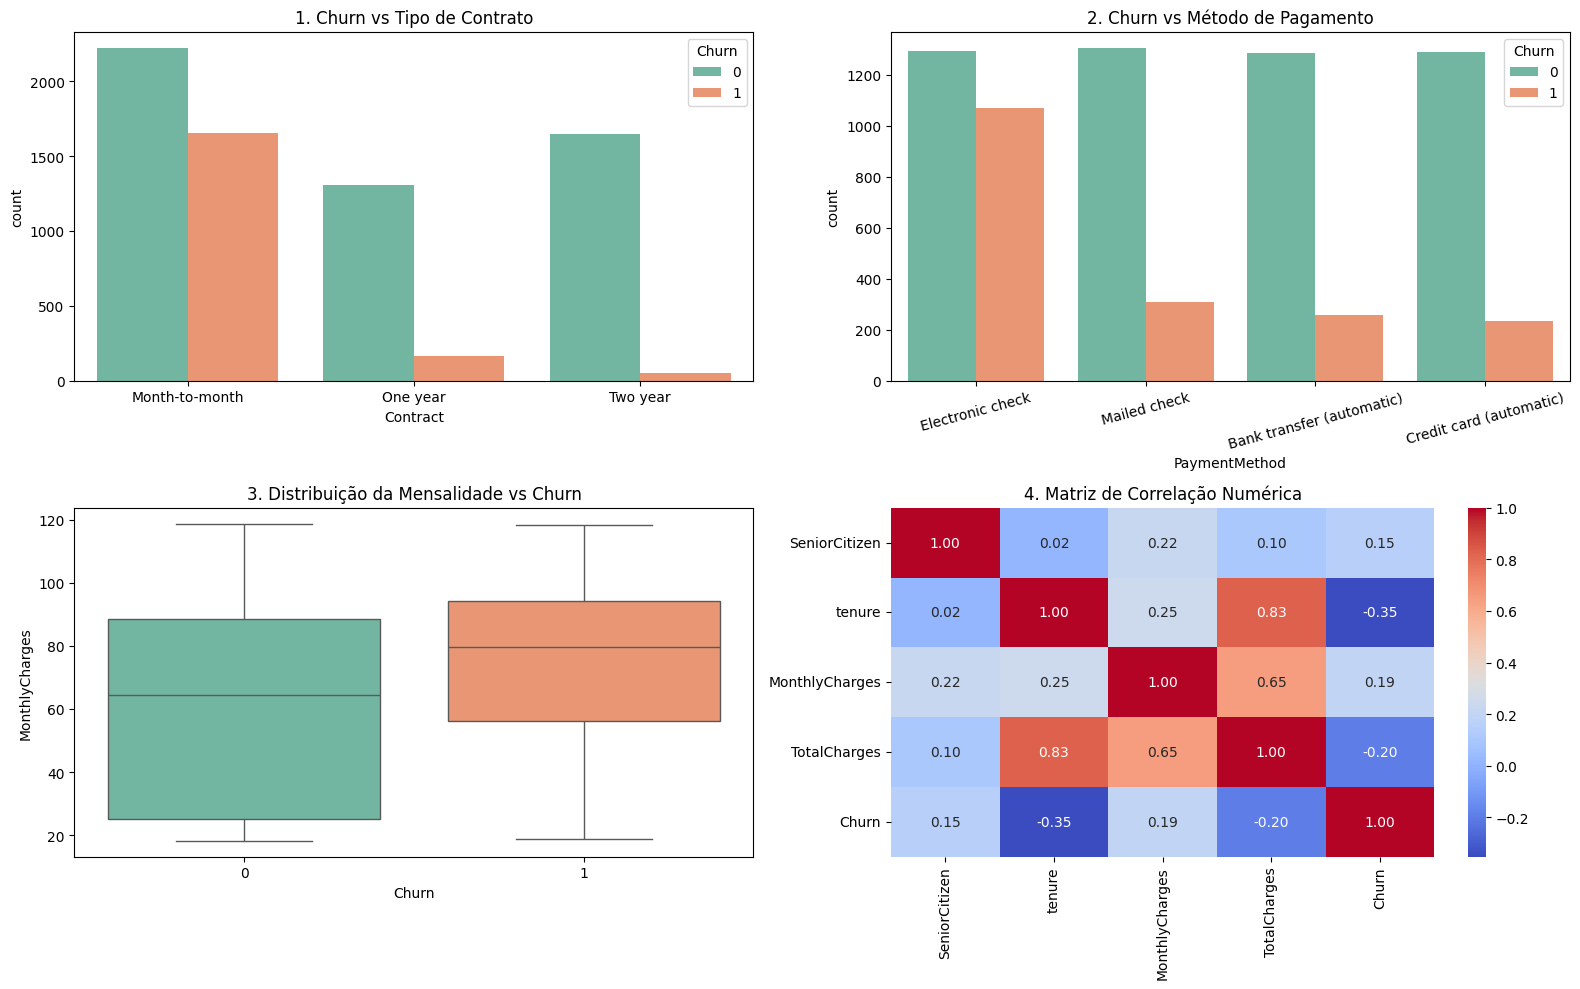

2026-04-06 22:29:18 | INFO     | notebook_eda | Análise visual concluída.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns

logger.info("Gerando painel de gráficos exploratórios detalhados...")

# Cria uma figura maior com 4 espaços (2 linhas, 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Variável Categórica: Tipo de Contrato
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('1. Churn vs Tipo de Contrato')

# 2. Variável Categórica: Método de Pagamento
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('2. Churn vs Método de Pagamento')
axes[0, 1].tick_params(axis='x', rotation=15) # Rotaciona o texto para não encavalar

# 3. Variável Numérica vs Target: Valor da Mensalidade (Boxplot)
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('3. Distribuição da Mensalidade vs Churn')

# 4. Correlação entre todas as numéricas
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('4. Matriz de Correlação Numérica')

plt.tight_layout()
plt.show()

logger.info("Análise visual concluída.")

###### Conclusões da Análise Exploratória (Insights de Negócio)

A partir do painel visual, identificam-se os seguintes padrões de comportamento em relação à variável alvo (`Churn`):

* ****1. Risco associado ao Tipo de Contrato:** Clientes com contratos de renovação mensal ("Month-to-month") apresentam a maior taxa absoluta e proporcional de cancelamento. A adoção de contratos de longo prazo (1 ou 2 anos) demonstra ser um fator crucial para a retenção.
* ****2. Fricção no Método de Pagamento:** O método "Electronic check" destaca-se negativamente, concentrando um alto volume de evasão. Em contrapartida, métodos com cobrança automatizada (cartão de crédito e transferência bancária) apresentam maior estabilidade.
* ****3. Sensibilidade a Preço (Mensalidade):** A distribuição no boxplot indica que a mediana do valor cobrado mensalmente (`MonthlyCharges`) é visivelmente maior no grupo de clientes que cancelaram o serviço, sugerindo que o custo da fatura é um motivador de atrito.
* ****4. Multicolinearidade e Tempo de Casa:** A matriz de correlação confirma a forte dependência linear (0.83) entre o tempo de permanência (`tenure`) e o valor acumulado (`TotalCharges`), um comportamento estatisticamente esperado. Destaca-se também a leve correlação negativa (-0.35) entre `tenure` e `Churn`, reforçando que clientes em estágio inicial do ciclo de vida têm maior propensão ao cancelamento.